# Classical ML pipeline

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

import sys
sys.path.insert(0, '../src')
from data_loader import load_and_epoch_data
from features import extract_features
from preprocessing import subject_aware_train_test_split

### Loading and epoching the data

In [2]:
X, labels = load_and_epoch_data(data_dir='../data/raw', overlap=0)

### Extracting features

In [3]:
X_features = extract_features(X, sfreq=128)
print(f"Features extracted: {X_features.shape}")

feature_names = ['Theta-Beta Ratio', 'Frontal Theta', 'Central Beta', 'Frontal Beta2', 'Entropy']
feature_df = pd.DataFrame(X_features, columns=feature_names)

print("\nFeature Statistics:")
print(feature_df.describe())

Features extracted: (4338, 5)

Feature Statistics:
       Theta-Beta Ratio  Frontal Theta  Central Beta  Frontal Beta2  \
count       4338.000000    4338.000000  4.338000e+03   4.338000e+03   
mean        1928.496398       1.377428  1.954155e-03   9.545962e-05   
std         2421.204072       0.986605  2.930532e-03   2.209998e-04   
min            1.439789       0.000002  1.690497e-07   2.113446e-08   
25%          528.664460       0.758179  6.670970e-04   1.876216e-05   
50%          974.998537       1.124674  1.507938e-03   5.025124e-05   
75%         2397.216916       1.687775  2.368973e-03   1.031218e-04   
max        28175.225902      11.703765  7.730105e-02   7.166234e-03   

           Entropy  
count  4338.000000  
mean      4.158485  
std       0.339801  
min       2.099850  
25%       3.993637  
50%       4.199661  
75%       4.384588  
max       5.172739  


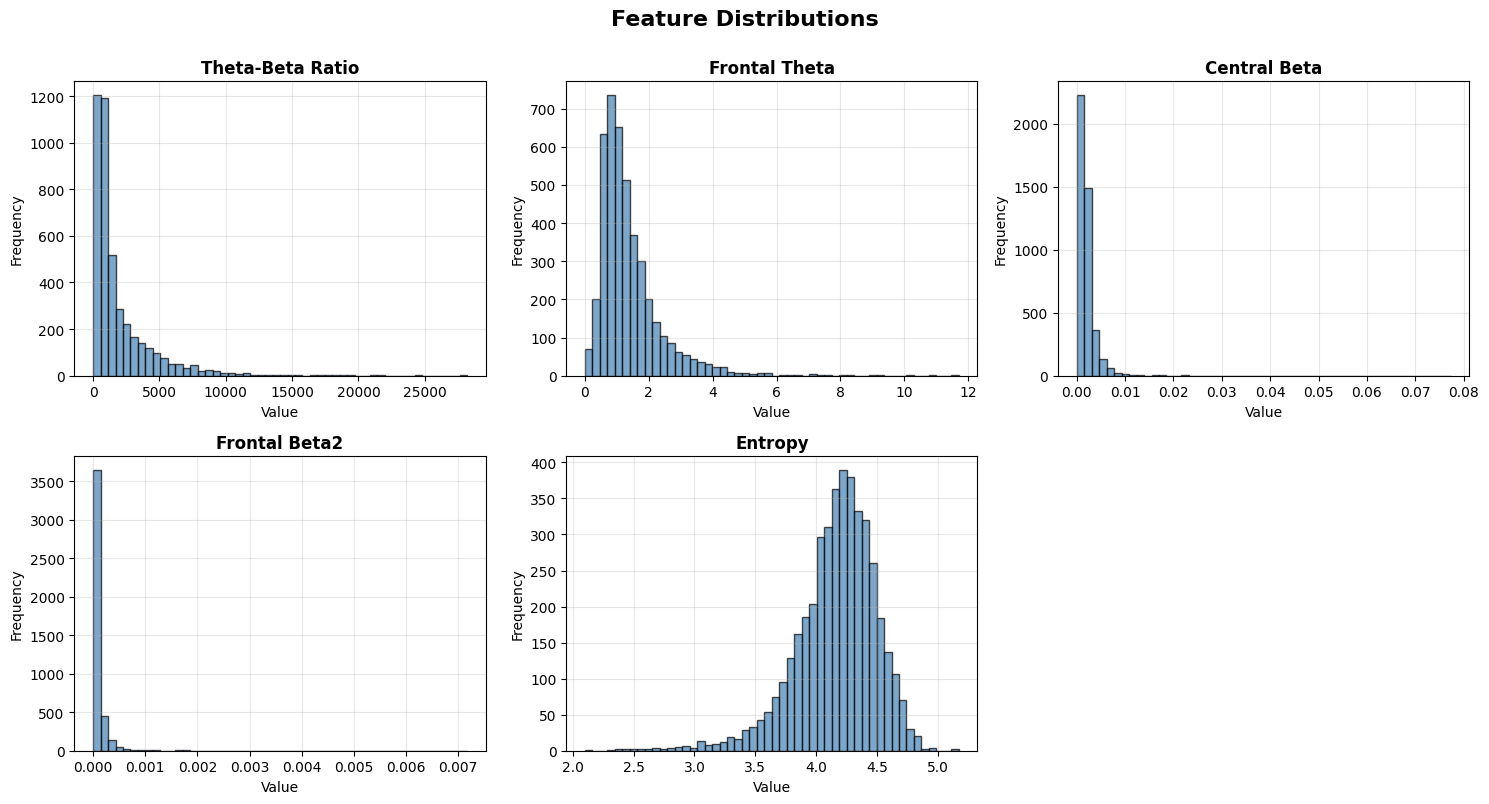

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(feature_names):
    axes[idx].hist(feature_df[col], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

axes[5].axis('off')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Train-Test split (subject aware)

In [5]:
X_train, X_test, y_train, y_test = subject_aware_train_test_split(
    X, X_features, labels, test_size=0.2, random_state=42
)

y_train_labels = y_train['session_type'] - 1
y_test_labels = y_test['session_type'] - 1

n_train_subjects = len(np.unique(y_train['subject_id']))
n_test_subjects = len(np.unique(y_test['subject_id']))

print(f"Train set: {X_train.shape[0]:,} epochs from {n_train_subjects} subjects")
print(f"Test set: {X_test.shape[0]:,} epochs from {n_test_subjects} subjects")
print(f"Class distribution (train): Normal = {sum(y_train_labels==0):,} | Mental Math = {sum(y_train_labels==1):,}")
print(f"Class distribution (test):  Normal = {sum(y_test_labels==0):,} | Mental Math = {sum(y_test_labels==1):,}")

Train set: 3,413 epochs from 28 subjects
Test set: 925 epochs from 8 subjects
Class distribution (train): Normal = 2,545 | Mental Math = 868
Class distribution (test):  Normal = 677 | Mental Math = 248


### Scaling features

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_scaled, y_train_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Evaluate

In [15]:
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*40)
print("MODEL PERFORMANCE METRICS")
print("="*40)

# Accuracy
train_acc = accuracy_score(y_train_labels, y_train_pred)
test_acc = accuracy_score(y_test_labels, y_test_pred)
overfit_gap = train_acc - test_acc

print(f"\n Accuracy:")
print(f"   Train: {train_acc:.4f}")
print(f"   Test:  {test_acc:.4f}")
print(f"   Overfitting Gap: {overfit_gap:.4f}")

# Precision, Recall, F1
test_prec = precision_score(y_test_labels, y_test_pred, zero_division=0)
test_rec = recall_score(y_test_labels, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test_labels, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test_labels, y_test_proba)

print(f"\n Test Set Metrics:")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall:    {test_rec:.4f}")
print(f"   F1 Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}")



MODEL PERFORMANCE METRICS

 Accuracy:
   Train: 0.7776
   Test:  0.6832
   Overfitting Gap: 0.0944

 Test Set Metrics:
   Precision: 0.4403
   Recall:    0.6694
   F1 Score:  0.5312
   AUC-ROC:   0.7028


### Plots


 Confusion Matrix:


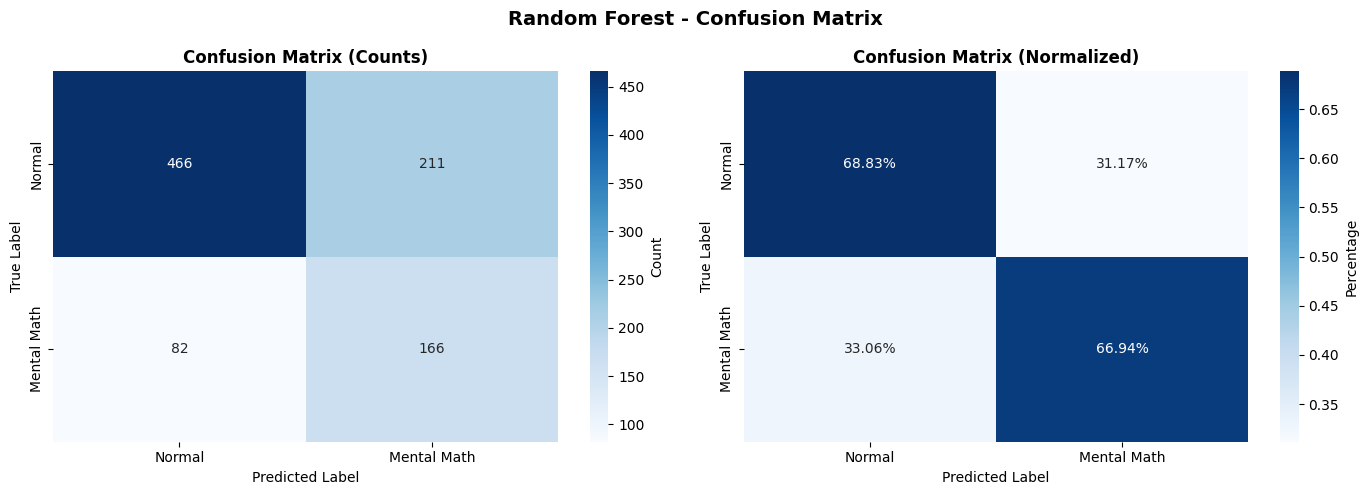


 Feature Importance:


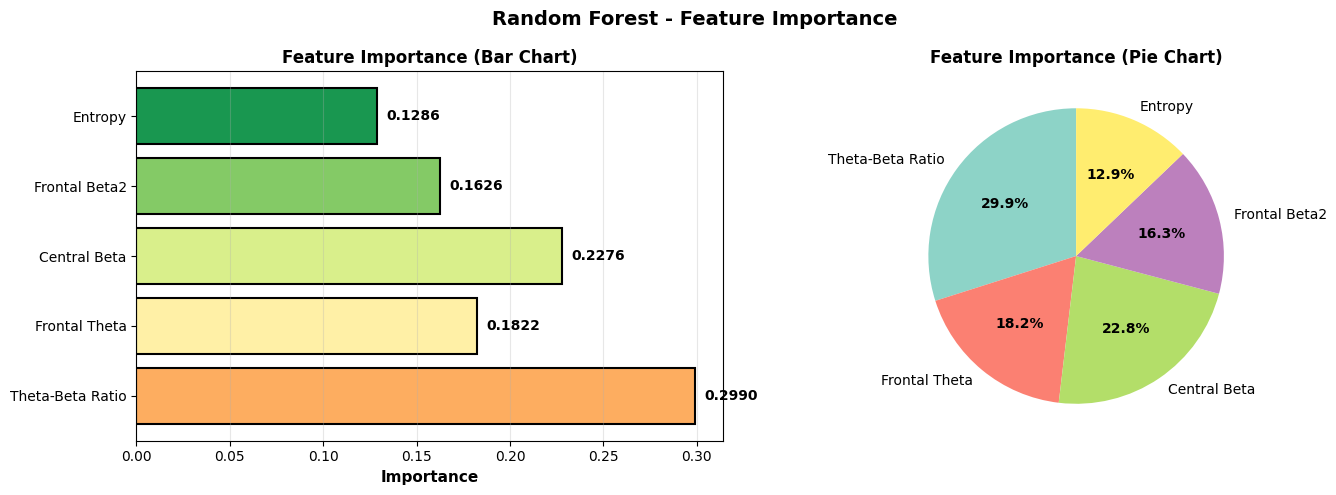


 ROC Curve:


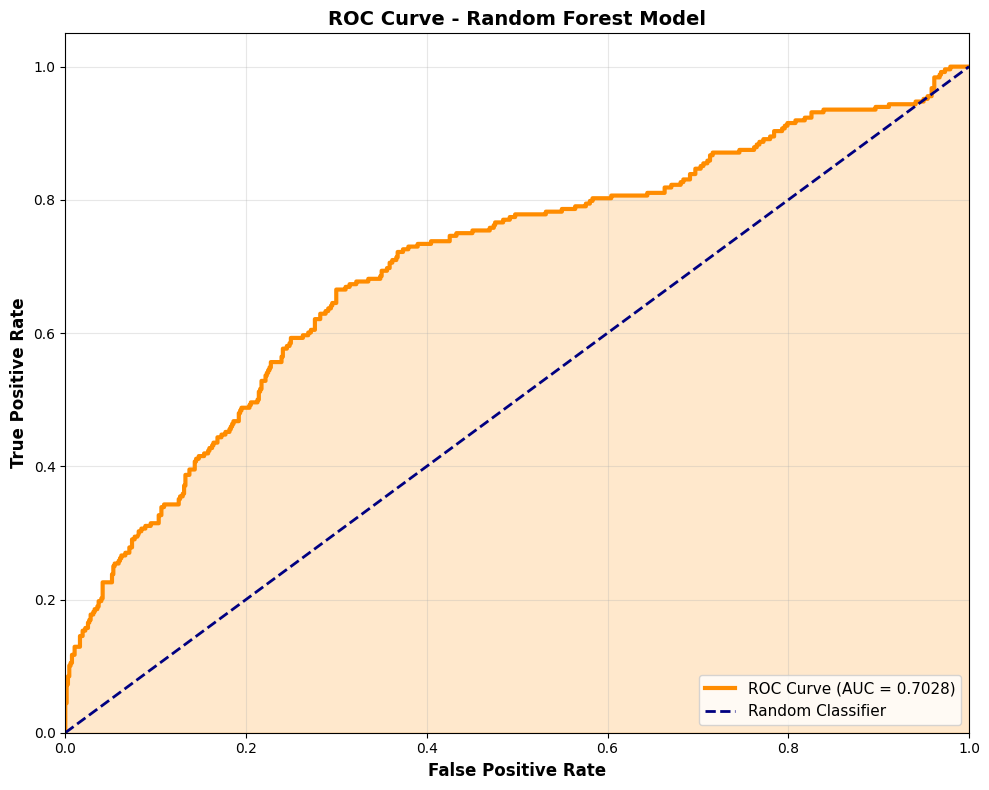


 Prediction Confidence Distribution:


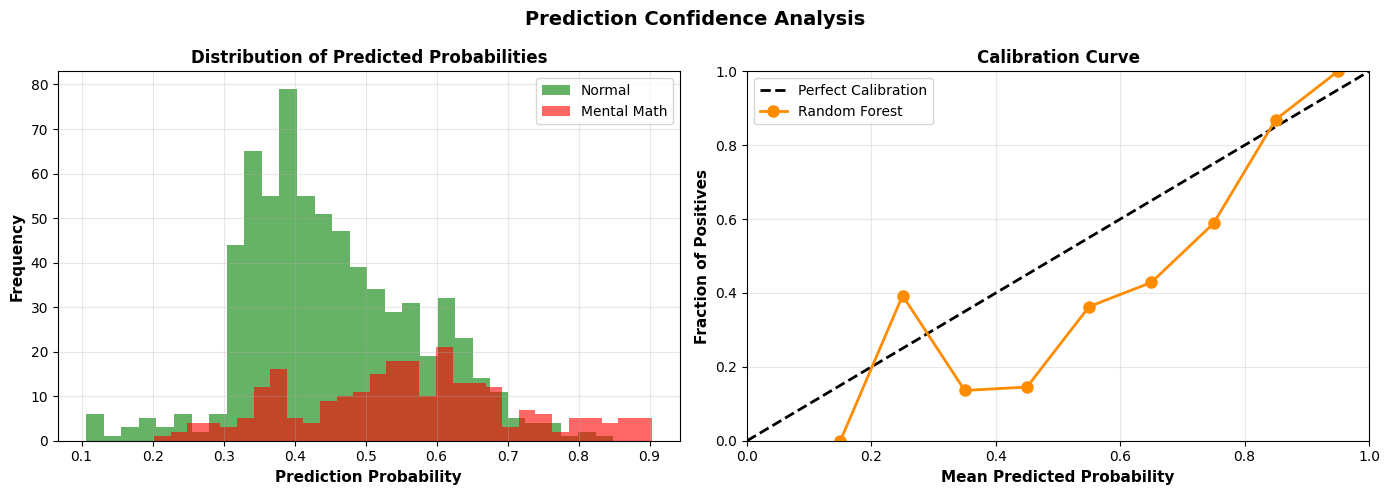


 Feature Correlation:


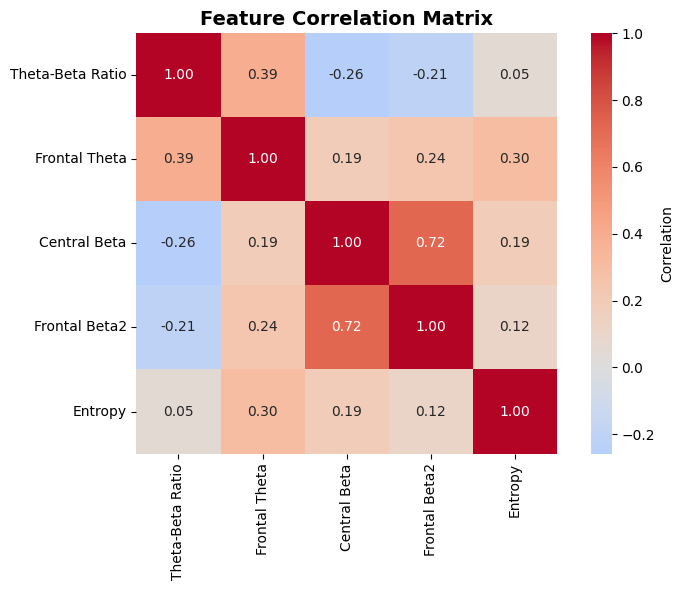


 Train vs Test Performance Comparison:


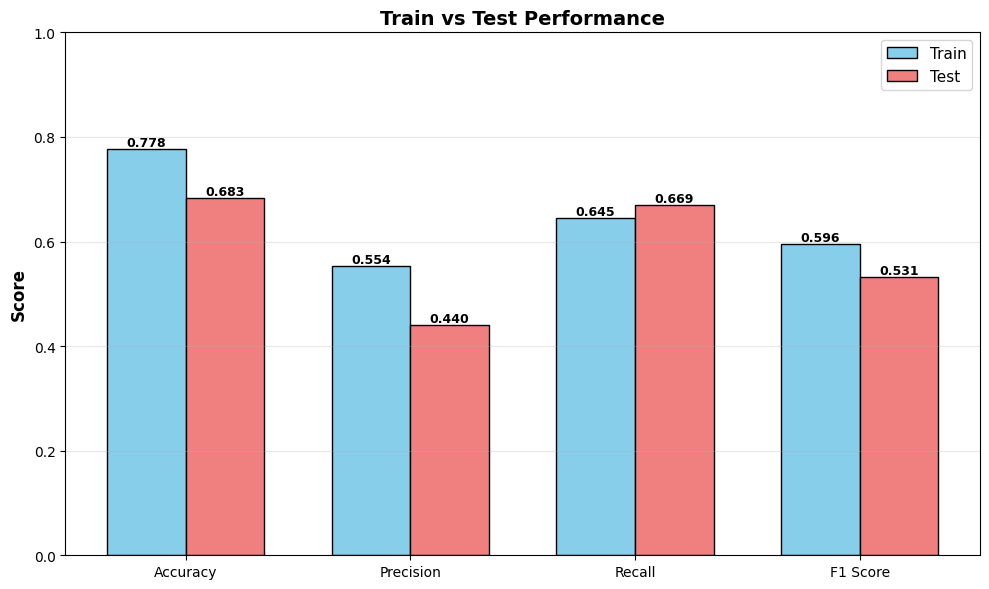


 Per-Class Performance:


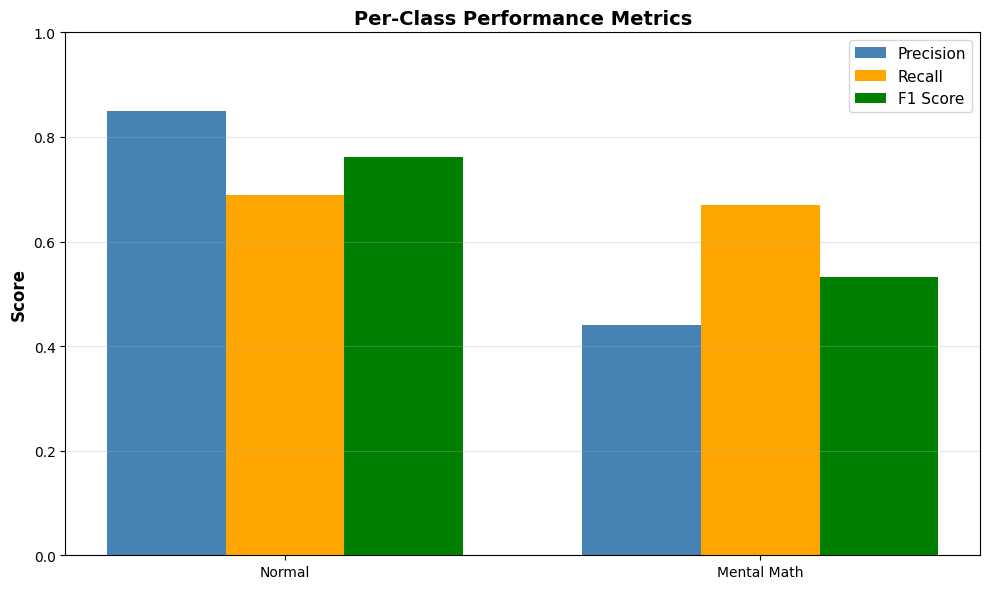

In [21]:
# Confusion Matrix

print(f"\n Confusion Matrix:")

cm = confusion_matrix(y_test_labels, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Mental Math'], yticklabels=['Normal', 'Mental Math'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Mental Math'], yticklabels=['Normal', 'Mental Math'],
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Importance

print(f"\n Feature Importance:")

importances = rf_model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_names)))
axes[0].barh(feature_names, importances, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[0].set_title('Feature Importance (Bar Chart)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(importances):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

# Pie chart
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(feature_names)))
wedges, texts, autotexts = axes[1].pie(importances, labels=feature_names, autopct='%1.1f%%',
                                         colors=colors_pie, startangle=90)
axes[1].set_title('Feature Importance (Pie Chart)', fontsize=12, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.suptitle('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC Curve

print(f"\n ROC Curve:")

fpr, tpr, thresholds = roc_curve(y_test_labels, y_test_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Random Forest Model', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Prediction Confidence Distribution

print(f"\n Prediction Confidence Distribution:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of probabilities
axes[0].hist(y_test_proba[y_test_labels == 0], bins=30, alpha=0.6, label='Normal', color='green')
axes[0].hist(y_test_proba[y_test_labels == 1], bins=30, alpha=0.6, label='Mental Math', color='red')
axes[0].set_xlabel('Prediction Probability', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Calibration curve (predicted vs actual)
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_sums = np.zeros(len(bins) - 1)
bin_true = np.zeros(len(bins) - 1)

for i in range(len(bins) - 1):
    mask = (y_test_proba >= bins[i]) & (y_test_proba < bins[i+1])
    if mask.sum() > 0:
        bin_true[i] = y_test_labels[mask].mean()
        bin_sums[i] = mask.sum()

axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
axes[1].plot(bin_centers[bin_sums > 0], bin_true[bin_sums > 0], 'o-', label='Random Forest',
            color='darkorange', linewidth=2, markersize=8)
axes[1].set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
axes[1].set_title('Calibration Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.suptitle('Prediction Confidence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Correlation

print(f"\n Feature Correlation:")

feature_corr = np.corrcoef(X_features.T)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=feature_names, yticklabels=feature_names,
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Train vs Test Performance Comparison

print(f"\n Train vs Test Performance Comparison:")

fig, ax = plt.subplots(figsize=(10, 6))

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_vals = [train_acc, 0, 0, 0]
test_vals = [test_acc, test_prec, test_rec, test_f1]

x = np.arange(len(metrics_list))
width = 0.35

bars1 = ax.bar(x - width/2, [train_acc, precision_score(y_train_labels, y_train_pred),
                             recall_score(y_train_labels, y_train_pred),
                             f1_score(y_train_labels, y_train_pred)],
              width, label='Train', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='lightcoral', edgecolor='black')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Per-Class Performance

print(f"\n Per-Class Performance:")

fig, ax = plt.subplots(figsize=(10, 6))

from sklearn.metrics import precision_recall_fscore_support
prec_per_class, rec_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test_labels, y_test_pred)

classes = ['Normal', 'Mental Math']
x = np.arange(len(classes))
width = 0.25

ax.bar(x - width, prec_per_class, width, label='Precision', color='steelblue')
ax.bar(x, rec_per_class, width, label='Recall', color='orange')
ax.bar(x + width, f1_per_class, width, label='F1 Score', color='green')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()